In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

# Load the cleaned dataset
df = pd.read_excel("cleaned_dataset.xlsx")

In [2]:
required_columns = [ 
    "customer_id", "first_name", "suggested_gender", "age", "city", "province", 
    "signup_date", "membership_tier", "purchase_count", "avg_order_value", 
    "suggested_total_spending", "last_purchase_days", "payment_method", "device", 
    "discount_used", "returned_items", "satisfaction_score" 
] 
  
missing_columns = [col for col in required_columns if col not in df.columns] 
if missing_columns: 
    raise ValueError(f"Missing columns: {missing_columns}")

### 1.Who Are the Store's Main Customers?

In [3]:
# Create age groups
  
age_bins = [0, 24, 34, 44, 54, 64, np.inf] 
age_labels = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

# Check the number of customers in each age group
age_distribution = df["age_group"].value_counts().sort_index()

age_distribution

age_group
Under 25     7
25-34       11
35-44       10
45-54       15
55-64       16
65+          1
Name: count, dtype: int64

In [4]:
# Calculate the distribution of each customer characteristic
gender_distribution = df["suggested_gender"].value_counts()
membership_distribution = df["membership_tier"].value_counts()
device_distribution = df["device"].value_counts()
payment_distribution = df["payment_method"].value_counts()

# Display the results
print("Gender Distribution:")
print(gender_distribution)

print("\nMembership Tier Distribution:")
print(membership_distribution)

print("\nDevice Distribution:")
print(device_distribution)

print("\nPayment Method Distribution:")
print(payment_distribution)

Gender Distribution:
suggested_gender
M    35
F    25
Name: count, dtype: int64

Membership Tier Distribution:
membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8
Name: count, dtype: int64

Device Distribution:
device
Android    22
Web        20
iPhone     18
Name: count, dtype: int64

Payment Method Distribution:
payment_method
Online Wallet    23
Cash             19
Card             18
Name: count, dtype: int64


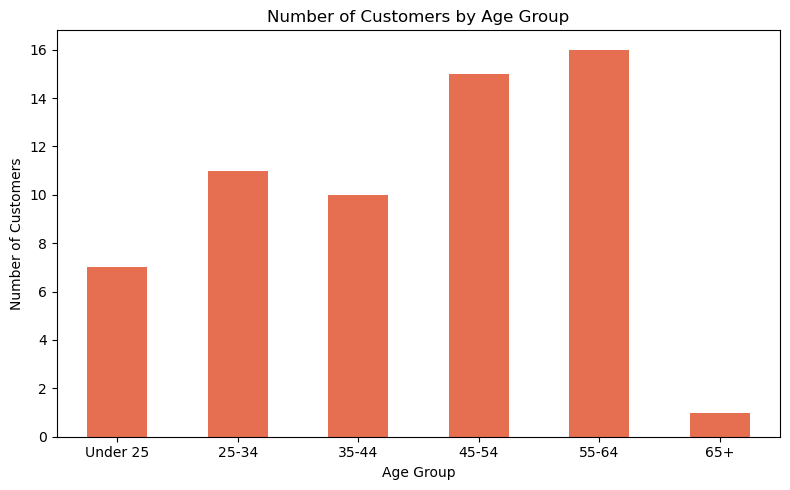

In [5]:
# Plot customer distribution by age group
plt.figure(figsize=(8, 5))

age_distribution.plot(kind="bar", color="#E76F51")

plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

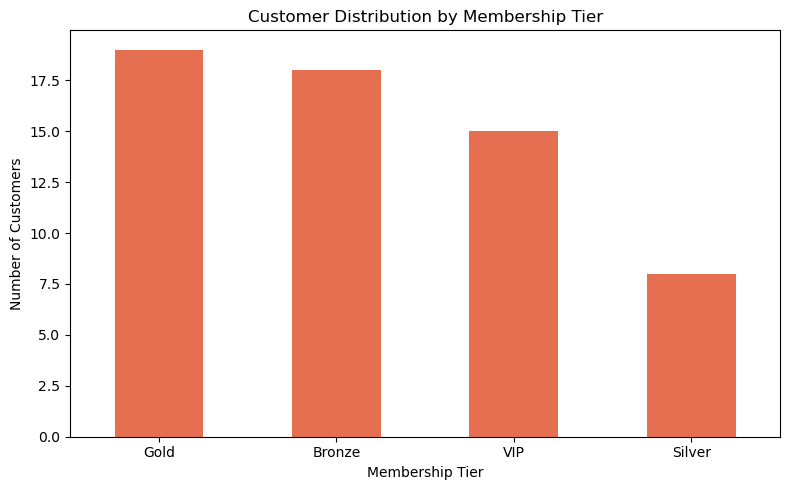

In [6]:
# Plot customer distribution by membership tier
plt.figure(figsize=(8, 5))

membership_distribution.plot(kind="bar", color="#E76F51")

plt.title("Customer Distribution by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

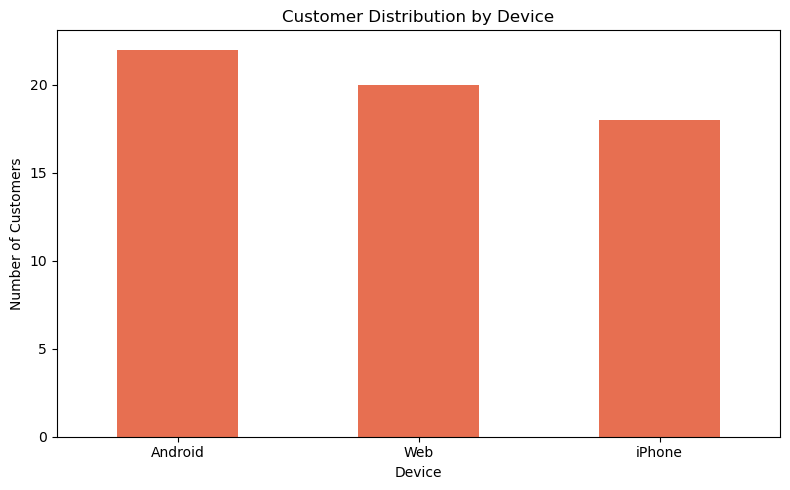

In [7]:
# Plot customer distribution by device
plt.figure(figsize=(8, 5))

device_distribution.plot(kind="bar", color="#E76F51")

plt.title("Customer Distribution by Device")
plt.xlabel("Device")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

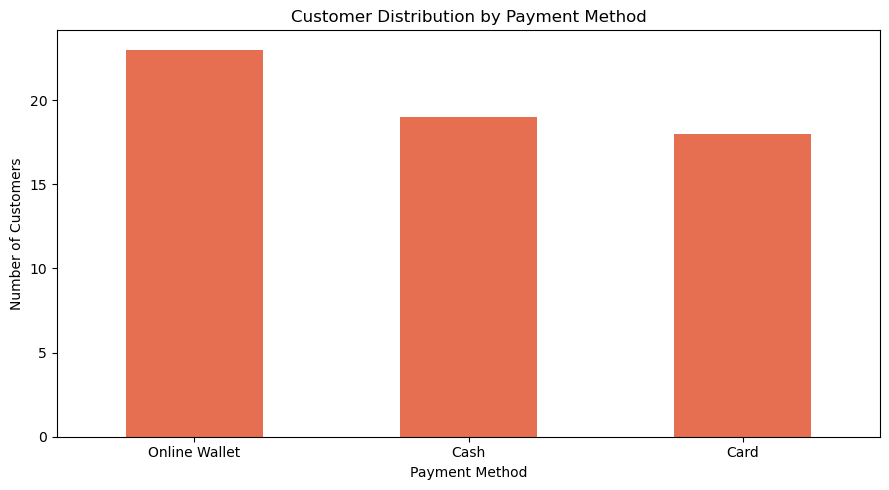

In [8]:
# Plot customer distribution by payment method
plt.figure(figsize=(9, 5))

payment_distribution.plot(kind="bar", color="#E76F51")

plt.title("Customer Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# Create a summary table of the dominant customer characteristics
summary_data = {
    "Characteristic": [
        "Age Group",
        "Gender",
        "Membership Tier",
        "Device",
        "Payment Method"
    ],
    "Dominant Group": [
        age_distribution.idxmax(),
        gender_distribution.idxmax(),
        membership_distribution.idxmax(),
        device_distribution.idxmax(),
        payment_distribution.idxmax()
    ],
    "Customer Count": [
        age_distribution.max(),
        gender_distribution.max(),
        membership_distribution.max(),
        device_distribution.max(),
        payment_distribution.max()
    ],
    "Percentage": [
        age_distribution.max() / len(df) * 100,
        gender_distribution.max() / len(df) * 100,
        membership_distribution.max() / len(df) * 100,
        device_distribution.max() / len(df) * 100,
        payment_distribution.max() / len(df) * 100
    ]
}

summary_table = pd.DataFrame(summary_data)

# Round percentages
summary_table["Percentage"] = summary_table["Percentage"].round(2)

display(
    summary_table.style.hide(axis="index")
)

Characteristic,Dominant Group,Customer Count,Percentage
Age Group,55-64,16,26.670000
Gender,M,35,58.330000
Membership Tier,Gold,19,31.670000
Device,Android,22,36.670000
Payment Method,Online Wallet,23,38.330000


In [10]:
# Extract the dominant characteristics
dominant_age = age_distribution.idxmax()
dominant_gender = gender_distribution.idxmax()
dominant_membership = membership_distribution.idxmax()
dominant_device = device_distribution.idxmax()
dominant_payment = payment_distribution.idxmax()

print("Dominant Customer Profile")
print("-------------------------")
print(f"Age Group: {dominant_age}")
print(f"Gender: {dominant_gender}")
print(f"Membership Tier: {dominant_membership}")
print(f"Device: {dominant_device}")
print(f"Payment Method: {dominant_payment}")

Dominant Customer Profile
-------------------------
Age Group: 55-64
Gender: M
Membership Tier: Gold
Device: Android
Payment Method: Online Wallet


Customer Profile Analysis:
The analysis shows that the largest customer age group is 55-64, with 16 customers (26.67%). Male customers represent the larger gender group with 35 customers (58.33%). Among membership tiers, Gold has the highest number of customers with 19 customers (31.67%). Android is the most commonly used device with 22 customers (36.67%), while Online Wallet is the most common payment method with 23 customers (38.33%). Based on these observed characteristics, the dominant customer characteristics in this dataset, considered individually, are male customer aged 55-64, with Gold membership, using an Android device and Online Wallet as the payment method. This profile describes the most common customer characteristics in the dataset and does not imply that this group is necessarily the most financially valuable.

### 2. Which province and city are the most suitable for advertising investment?

In [11]:
# Prepare data for location analysis
location_df = df[
    [
        "province",
        "city",
        "customer_id",
        "suggested_total_spending",
        "purchase_count",
        "avg_order_value",
        "satisfaction_score"
    ]
].copy()

In [12]:
# Aggregate customer metrics at the city level
city_summary = (
    location_df
    .groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("suggested_total_spending", "sum"),
        avg_customer_spending=("suggested_total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

# Keep cities with at least three customers
city_summary = city_summary[
    city_summary["customer_count"] >= 3
].copy()

city_summary.head().style.hide(axis="index")

province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
Alborz,Karaj,7,26189.810000,3741.401429,16.000000,211.440000,2.857143
East Azerbaijan,Tabriz,12,36192.490000,3016.040833,15.750000,238.901667,3.000000
Fars,Shiraz,6,20715.920000,3452.653333,16.333333,180.983333,2.000000
Gilan,Rasht,5,15168.540000,3033.708000,16.400000,241.554000,2.600000
Isfahan,Isfahan,5,21975.320000,4395.064000,19.800000,212.680000,4.400000


In [13]:
# Aggregate customer metrics at the province level
province_summary = (
    location_df
    .groupby("province", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("suggested_total_spending", "sum"),
        avg_customer_spending=("suggested_total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

# Sort provinces by total customer spending
province_summary = province_summary.sort_values(
    "total_revenue",
    ascending=False
)

display(
    province_summary.style.hide(axis="index")
)

province,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
Khorasan,11,43197.580000,3927.052727,22.636364,210.508182,2.909091
East Azerbaijan,12,36192.490000,3016.040833,15.750000,238.901667,3.000000
Alborz,7,26189.810000,3741.401429,16.000000,211.440000,2.857143
Khuzestan,8,23384.780000,2923.097500,13.875000,216.531250,3.500000
Isfahan,5,21975.320000,4395.064000,19.800000,212.680000,4.400000
Fars,6,20715.920000,3452.653333,16.333333,180.983333,2.000000
Gilan,5,15168.540000,3033.708000,16.400000,241.554000,2.600000
Tehran,6,15161.290000,2526.881667,17.166667,172.930000,2.666667


In [14]:
# Identify the top 10 cities by total customer spending
top_cities = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

display(
    top_cities.sort_values(
        "total_revenue",
        ascending=False
    ).style.hide(axis="index")
)

province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
Khorasan,Mashhad,11,43197.580000,3927.052727,22.636364,210.508182,2.909091
East Azerbaijan,Tabriz,12,36192.490000,3016.040833,15.750000,238.901667,3.000000
Alborz,Karaj,7,26189.810000,3741.401429,16.000000,211.440000,2.857143
Khuzestan,Ahvaz,8,23384.780000,2923.097500,13.875000,216.531250,3.500000
Isfahan,Isfahan,5,21975.320000,4395.064000,19.800000,212.680000,4.400000
Fars,Shiraz,6,20715.920000,3452.653333,16.333333,180.983333,2.000000
Gilan,Rasht,5,15168.540000,3033.708000,16.400000,241.554000,2.600000
Tehran,Tehran,6,15161.290000,2526.881667,17.166667,172.930000,2.666667


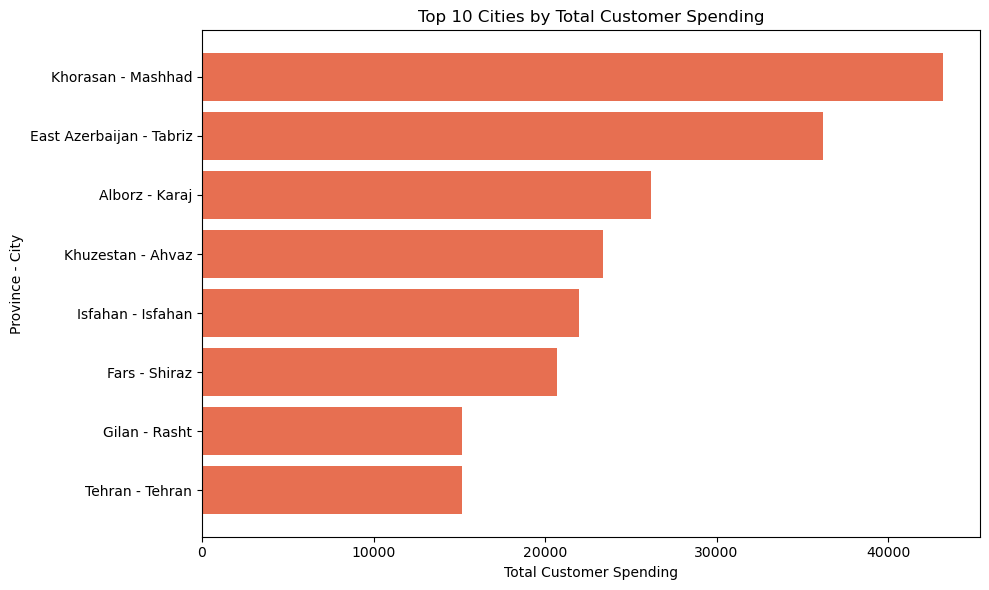

In [15]:
# Create labels combining province and city
labels = (
    top_cities["province"]
    + " - "
    + top_cities["city"]
)

# Plot the top 10 cities by total customer spending
plt.figure(figsize=(10, 6))

plt.barh(
    labels,
    top_cities["total_revenue"],
    color="#E76F51"
)

plt.title("Top 10 Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")
plt.ylabel("Province - City")

plt.tight_layout()
plt.show()

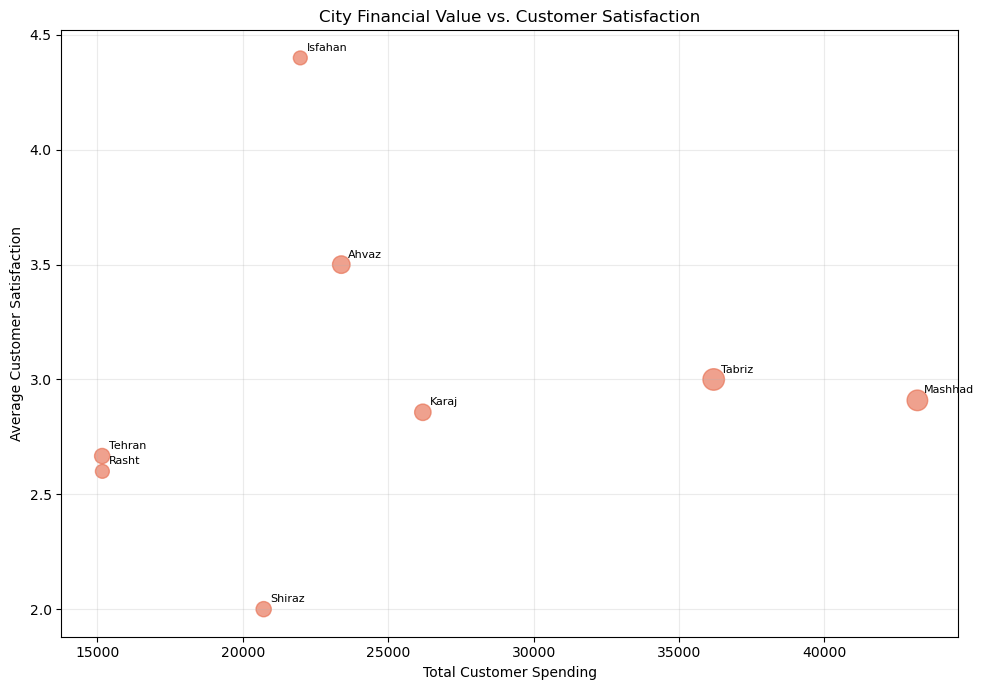

province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
Khorasan,Mashhad,11,43197.580000,3927.052727,22.636364,210.508182,2.909091
East Azerbaijan,Tabriz,12,36192.490000,3016.040833,15.750000,238.901667,3.000000
Alborz,Karaj,7,26189.810000,3741.401429,16.000000,211.440000,2.857143
Khuzestan,Ahvaz,8,23384.780000,2923.097500,13.875000,216.531250,3.500000
Isfahan,Isfahan,5,21975.320000,4395.064000,19.800000,212.680000,4.400000
Fars,Shiraz,6,20715.920000,3452.653333,16.333333,180.983333,2.000000
Gilan,Rasht,5,15168.540000,3033.708000,16.400000,241.554000,2.600000
Tehran,Tehran,6,15161.290000,2526.881667,17.166667,172.930000,2.666667


In [16]:
# Create a labeled scatter plot
plt.figure(figsize=(10, 7))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65,
    color="#E76F51"
)

# Add city labels
for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("City Financial Value vs. Customer Satisfaction")
plt.xlabel("Total Customer Spending")
plt.ylabel("Average Customer Satisfaction")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# Compare cities across multiple business metrics
city_comparison = city_summary.sort_values(
    ["total_revenue", "customer_count", "avg_order_value", "avg_satisfaction"],
    ascending=[False, False, False, False]
)

display(city_comparison.style.hide(axis="index"))

Location Analysis:
Mashhad is the strongest candidate for advertising investment based on the combination of customer volume, total spending, average customer spending, and purchase frequency. It has 11 customers, the highest total spending of 43,197.58, an average customer spending of 3,927.05, and the highest average purchase count of 22.64. However, its average satisfaction score of 2.91 indicates that customer experience should be considered before significantly increasing acquisition efforts.

Isfahan is a potential alternative. Although it has only 5 customers and a lower total spending of 21,975.32, it has the highest average customer spending at 4,395.06 and the highest satisfaction score at 4.40. Therefore, Isfahan may represent a smaller but higher-value and more satisfied customer segment.

Based on these observations, Mashhad is recommended as the primary advertising market because of its stronger customer volume and overall financial contribution, while Isfahan can be considered a secondary market focused on high-value customers. Cities with high revenue but relatively low satisfaction should be approached carefully because increasing advertising investment without addressing customer experience may increase exposure to dissatisfaction.

### 3.Which Customers Should Be Prioritized for the Loyalty Program?

In [17]:
# Prepare data for loyalty program analysis
loyalty_df = df[
    [
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "suggested_total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].copy()

In [18]:
# Normalize financial value, purchase frequency, and satisfaction
for column in [
    "purchase_count",
    "suggested_total_spending",
    "satisfaction_score"
]:
    minimum = loyalty_df[column].min()
    maximum = loyalty_df[column].max()

    if maximum == minimum:
        loyalty_df[f"{column}_score"] = 1.0
    else:
        loyalty_df[f"{column}_score"] = (
            loyalty_df[column] - minimum
        ) / (maximum - minimum)

In [19]:
# Calculate the recency score
recency_min = loyalty_df["last_purchase_days"].min()
recency_max = loyalty_df["last_purchase_days"].max()

if recency_max == recency_min:
    loyalty_df["recency_score"] = 1.0
else:
    loyalty_df["recency_score"] = 1 - (
        (loyalty_df["last_purchase_days"] - recency_min)
        / (recency_max - recency_min)
    )

In [20]:
# Calculate the overall loyalty score
loyalty_df["loyalty_score"] = (
    0.35 * loyalty_df["suggested_total_spending_score"]
    + 0.30 * loyalty_df["purchase_count_score"]
    + 0.20 * loyalty_df["recency_score"]
    + 0.15 * loyalty_df["satisfaction_score_score"]
)

In [21]:
# Sensitivity Analysis for Loyalty Score

scenarios = {
    "1": [0.35, 0.30, 0.20, 0.15],  # Current weights
    "2": [0.40, 0.30, 0.20, 0.10],
    "3": [0.30, 0.35, 0.20, 0.15],
    "4": [0.35, 0.25, 0.25, 0.15],
    "5": [0.35, 0.30, 0.15, 0.20]
}

top10_results = {}

for scenario, weights in scenarios.items():
    score = (
        weights[0] * loyalty_df["suggested_total_spending_score"]
        + weights[1] * loyalty_df["purchase_count_score"]
        + weights[2] * loyalty_df["recency_score"]
        + weights[3] * loyalty_df["satisfaction_score_score"]
    )

    top10_results[scenario] = set(
        loyalty_df.assign(temp_score=score)
        .nlargest(10, "temp_score")["customer_id"]
    )

base_top10 = top10_results["1"]

for scenario, customers in top10_results.items():
    overlap = len(base_top10.intersection(customers))
    overlap_pct = overlap / 10 * 100

    print(
        f"Scenario {scenario}: "
        f"{overlap}/10 customers overlap "
        f"({overlap_pct:.0f}%) with the current Top 10"
    )

Scenario 1: 10/10 customers overlap (100%) with the current Top 10
Scenario 2: 10/10 customers overlap (100%) with the current Top 10
Scenario 3: 10/10 customers overlap (100%) with the current Top 10
Scenario 4: 9/10 customers overlap (90%) with the current Top 10
Scenario 5: 10/10 customers overlap (100%) with the current Top 10


In [22]:
# Select the top 10 customers for the loyalty program
top_loyal_customers = (
    loyalty_df
    .nlargest(10, "loyalty_score")
    [
        [
            "customer_id",
            "first_name",
            "membership_tier",
            "purchase_count",
            "suggested_total_spending",
            "last_purchase_days",
            "satisfaction_score",
            "loyalty_score"
        ]
    ]
    .copy()
)

In [23]:
# Assign at least one selection reason to every selected customer
top_loyal_customers["selection_reason"] = ""

spending_q75 = loyalty_df["suggested_total_spending"].quantile(0.75)
purchase_q75 = loyalty_df["purchase_count"].quantile(0.75)
recency_q25 = loyalty_df["last_purchase_days"].quantile(0.25)
satisfaction_q75 = loyalty_df["satisfaction_score"].quantile(0.75)

for index, row in top_loyal_customers.iterrows():

    reasons = []

    if row["suggested_total_spending"] >= spending_q75:
        reasons.append("High spending")

    if row["purchase_count"] >= purchase_q75:
        reasons.append("High purchase frequency")

    if row["last_purchase_days"] <= recency_q25:
        reasons.append("Recent activity")

    if row["satisfaction_score"] >= satisfaction_q75:
        reasons.append("High satisfaction")

    if not reasons:
        reasons.append("Strong overall loyalty score")

    top_loyal_customers.loc[index, "selection_reason"] = ", ".join(reasons)

display(
    top_loyal_customers.style.hide(axis="index")
)

customer_id,first_name,membership_tier,purchase_count,suggested_total_spending,last_purchase_days,satisfaction_score,loyalty_score,selection_reason
1057,Maryam,Bronze,31,13532.740000,82,4,0.864535,"High spending, High purchase frequency, Recent activity, High satisfaction"
1044,Mina,Gold,33,14354.340000,165,2,0.780854,"High spending, High purchase frequency"
1059,Ali,Gold,31,8898.550000,224,5,0.710587,"High spending, High purchase frequency, High satisfaction"
1009,Kimia,Silver,34,11615.420000,232,2,0.685627,"High spending, High purchase frequency"
1004,Sina,Gold,23,6121.450000,40,4,0.638459,"High spending, Recent activity, High satisfaction"
1012,Arash,Gold,27,11731.500000,224,2,0.632877,"High spending, High purchase frequency"
1033,Neda,VIP,24,5521.200000,112,5,0.630116,"High spending, Recent activity, High satisfaction"
1014,Reza,VIP,31,3353.890000,97,4,0.608058,"High purchase frequency, Recent activity, High satisfaction"
1023,Ali,Bronze,31,3851.440000,170,4,0.579858,"High purchase frequency, High satisfaction"
1017,Parsa,VIP,30,3239.400000,135,4,0.575701,"High purchase frequency, High satisfaction"


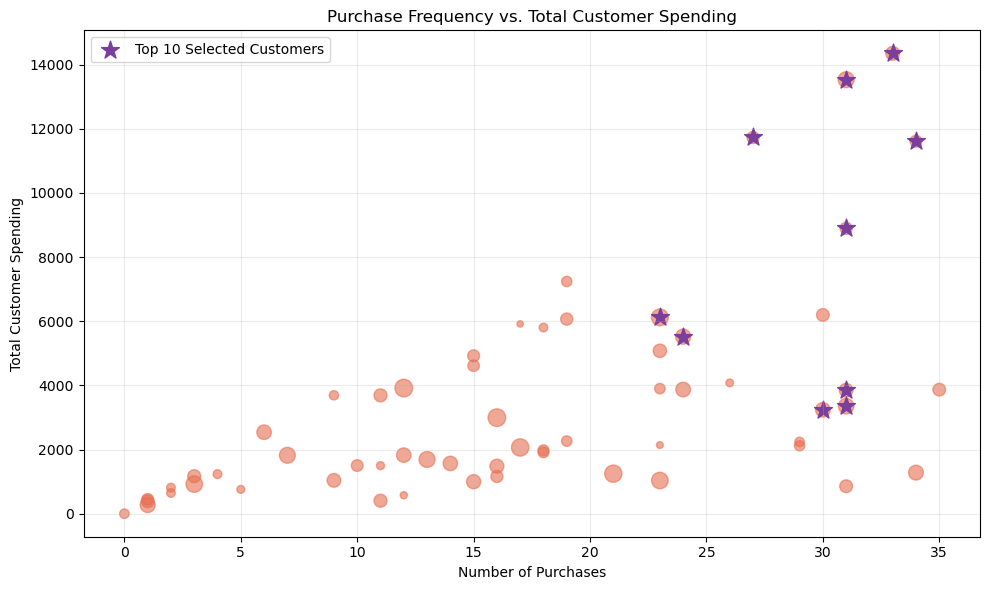

In [24]:
# Plot purchase frequency against total customer spending
plt.figure(figsize=(10, 6))

plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["suggested_total_spending"],
    s=(loyalty_df["recency_score"] + 0.15) * 140,
    alpha=0.6,
    color="#E76F51"
)

# Highlight the selected top 10 customers
plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["suggested_total_spending"],
    s=180,
    marker="*",
    color="#7A3E9D",
    label="Top 10 Selected Customers"
)

plt.title("Purchase Frequency vs. Total Customer Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Customer Spending")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Loyalty Program Analysis:

The loyalty score combines financial value, purchase frequency, recency, and customer satisfaction. Total spending received the highest weight (35%) because financial value is the primary consideration for a limited loyalty program. Purchase frequency received 30% to reward repeated purchasing behavior, while recency received 20% to prevent customers with high historical spending but long periods of inactivity from being automatically prioritized. Satisfaction received 15% as a complementary indicator of customer relationship quality.

The selected customers generally show strong purchase frequency and/or financial value, while the recency and satisfaction components prevent the selection from being based only on membership tier. For example, Maryam has the highest loyalty score (0.865), supported by high spending, high purchase frequency, recent activity, and high satisfaction. Mina also has high spending and purchase frequency, although her last purchase was 165 days ago and her satisfaction score is lower.

The results also show that membership tier does not always correspond to the calculated loyalty score. For example, some Bronze and Silver customers rank above certain VIP customers. This indicates that current membership status alone may not accurately represent behavioral loyalty or financial value.

A customer with very high total spending but a very old last purchase should not automatically receive the same loyalty benefit as an equally valuable but recently active customer. The recency component is therefore important when allocating a limited number of loyalty rewards.

A sensitivity analysis was also performed by moderately changing the weighting scheme. The Top 10 customers remained unchanged in three of the four alternative scenarios, while 9 out of 10 customers remained in the Top 10 under the fourth scenario. This indicates that the loyalty ranking is relatively robust to moderate changes in the selected weights.

### 4.Which High-Value Customers Are at Risk of Becoming Inactive?

In [25]:
# Prepare data for customer risk analysis
risk_df = df[
    [
        "customer_id",
        "first_name",
        "suggested_total_spending",
        "purchase_count",
        "last_purchase_days",
        "membership_tier",
        "satisfaction_score"
    ]
].copy()

In [26]:
# Define thresholds for customer value and inactivity
spending_threshold = risk_df["suggested_total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

In [27]:
# Identify valuable customers who are at risk of becoming inactive
risk_df["at_risk"] = (
    (risk_df["suggested_total_spending"] >= spending_threshold)
    & (risk_df["purchase_count"] >= purchase_threshold)
    & (risk_df["last_purchase_days"] >= inactivity_threshold)
)

In [28]:
# Create the target list for the win-back campaign
at_risk_customers = (
    risk_df.loc[
        risk_df["at_risk"],
        [
            "customer_id",
            "first_name",
            "membership_tier",
            "purchase_count",
            "suggested_total_spending",
            "last_purchase_days",
            "satisfaction_score"
        ]
    ]
    .sort_values(
        ["suggested_total_spending", "last_purchase_days"],
        ascending=[False, False]
    )
)

display(
    at_risk_customers.style.hide(axis="index")
)

print(
    f"Number of valuable at-risk customers: {len(at_risk_customers)}"
)

customer_id,first_name,membership_tier,purchase_count,suggested_total_spending,last_purchase_days,satisfaction_score
1010,Arash,Silver,19,7241.470000,276,1
1035,Arash,Bronze,17,5918.210000,365,3
1053,Sina,Gold,18,5805.540000,320,1


Number of valuable at-risk customers: 3


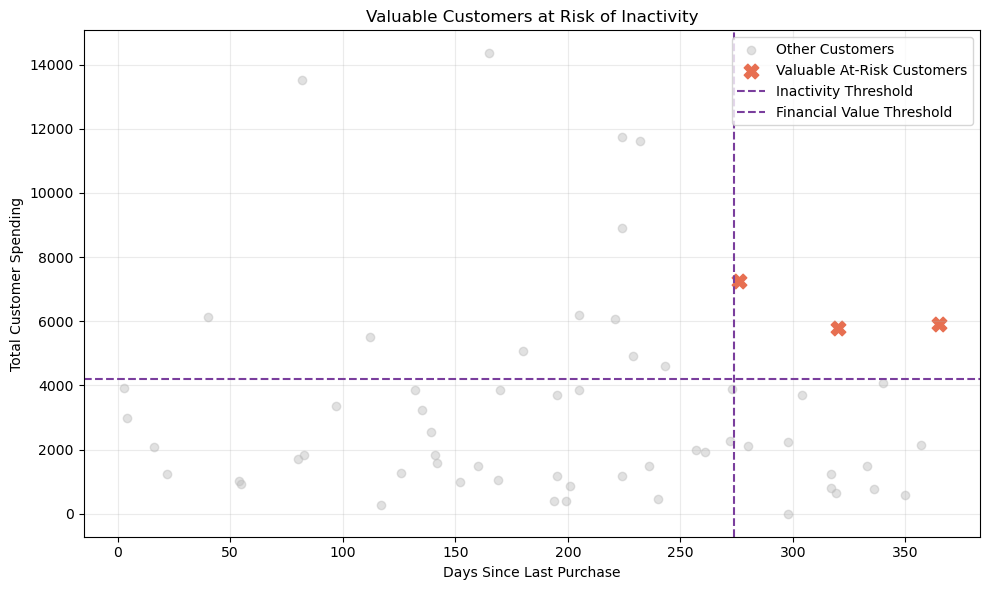

In [29]:
# Plot customer inactivity against financial value
plt.figure(figsize=(10, 6))

# Plot other customers
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "suggested_total_spending"],
    alpha=0.45,
    color="#BDBDBD",
    label="Other Customers"
)

# Highlight valuable at-risk customers
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "suggested_total_spending"],
    marker="X",
    s=110,
    color="#E76F51",
    label="Valuable At-Risk Customers"
)

# Add thresholds
plt.axvline(
    inactivity_threshold,
    linestyle="--",
    color="#7A3E9D",
    label="Inactivity Threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    color="#7A3E9D",
    label="Financial Value Threshold"
)

plt.title("Valuable Customers at Risk of Inactivity")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Customer Spending")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [30]:
# Define the satisfaction threshold
satisfaction_threshold = risk_df["satisfaction_score"].median()

# Classify at-risk customers based on satisfaction
at_risk_customers["customer_status"] = (
    at_risk_customers["satisfaction_score"]
    .apply(
        lambda x: "Dissatisfied" if x < satisfaction_threshold
        else "Satisfied but Inactive"
    )
)

display(
    at_risk_customers.style.hide(axis="index")
)

customer_id,first_name,membership_tier,purchase_count,suggested_total_spending,last_purchase_days,satisfaction_score,customer_status
1010,Arash,Silver,19,7241.470000,276,1,Dissatisfied
1035,Arash,Bronze,17,5918.210000,365,3,Satisfied but Inactive
1053,Sina,Gold,18,5805.540000,320,1,Dissatisfied


In [31]:
# Count at-risk customers by satisfaction status
status_summary = (
    at_risk_customers["customer_status"]
    .value_counts()
)

display(status_summary)

customer_status
Dissatisfied              2
Satisfied but Inactive    1
Name: count, dtype: int64

At-Risk Customer Analysis:
In this analysis, a valuable at-risk customer is defined as a customer whose total spending is at or above the 75th percentile, whose purchase frequency is at or above the median, and whose number of days since the last purchase is at or above the 75th percentile. Based on these criteria, 3 customers were identified as potential targets for a win-back campaign.

The three customers are Arash (customer 1010), Arash (customer 1035), and Sina (customer 1053). Arash (1010) has the highest financial value at 7,241.47 but also has a low satisfaction score of 1 and has not purchased for 276 days. Sina has 5,805.54 in total spending, a satisfaction score of 1, and 320 days since the last purchase. Arash (1035) has spent 5,918.21 and has the longest inactivity period at 365 days, while his satisfaction score of 3 suggests that inactivity may be a more important issue than dissatisfaction.

Therefore, the first two customers with low satisfaction should receive a personalized recovery approach that addresses their negative experience rather than relying only on a discount. The satisfied-but-inactive customer should receive a re-engagement offer designed to encourage a return purchase.

The upper-right region of the scatter plot contains 3 customers who simultaneously have relatively high financial value and long inactivity periods. Two of these customers have low satisfaction, while one appears to be inactive without a low satisfaction score. These customers should be prioritized for immediate personalized contact.

However, these results indicate potential inactivity risk rather than confirmed customer churn. The dataset contains only the number of days since the last purchase and does not provide a complete historical order timeline; therefore, actual customer churn cannot be conclusively established.

### 5.How Are Discounts, Devices, and Payment Methods Related to Customer Behavior?


In [32]:
# Prepare data for descriptive factor analysis
factor_df = df[
    [
        "customer_id",
        "discount_used",
        "device",
        "payment_method",
        "suggested_total_spending",
        "purchase_count",
        "avg_order_value",
        "returned_items",
        "satisfaction_score"
    ]
].copy()

In [33]:
# Compare customer behavior based on discount usage
summary_by_discount = (
    factor_df
    .groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("suggested_total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

display(
    summary_by_discount.style.hide(axis="index")
)

discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
False,34,3736.741176,17.294118,220.700588,4.264706,2.764706
True,26,2882.174231,17.500000,203.291154,4.076923,3.269231


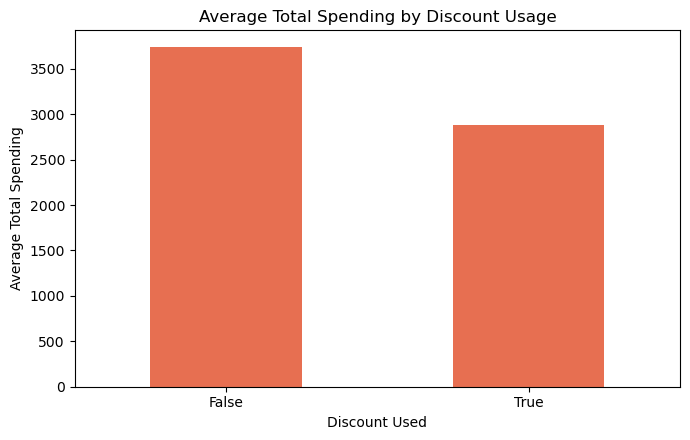

In [34]:
# Compare average total spending by discount usage
summary_by_discount.plot(
    x="discount_used",
    y="avg_total_spending",
    kind="bar",
    legend=False,
    figsize=(7, 4.5),
    color="#E76F51"
)

plt.title("Average Total Spending by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

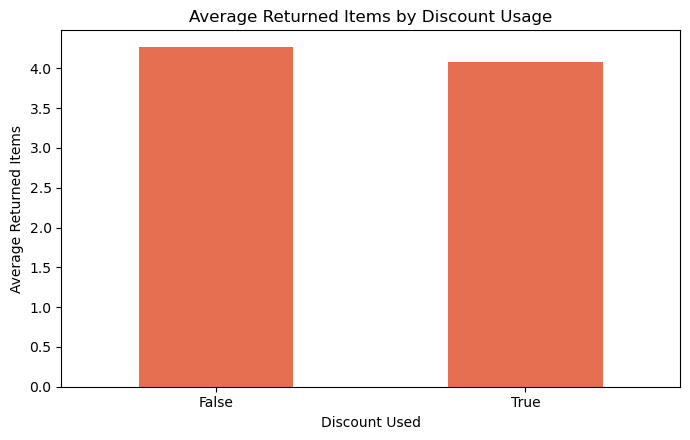

In [35]:
# Compare average returned items by discount usage
summary_by_discount.plot(
    x="discount_used",
    y="avg_returned_items",
    kind="bar",
    legend=False,
    figsize=(7, 4.5),
    color="#E76F51"
)

plt.title("Average Returned Items by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Returned Items")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [36]:
# Summarize customer value by device
device_summary = (
    factor_df
    .groupby("device", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("suggested_total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

device_summary = device_summary[
    device_summary["customer_count"] >= 3
].sort_values(
    "avg_total_spending",
    ascending=False
)

display(
    device_summary.style.hide(axis="index")
)

device,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
iPhone,18,3773.945000,18.277778,204.661111,3.333333,2.944444
Android,22,3459.069091,17.909091,209.785455,4.772727,3.090909
Web,20,2897.760000,16.000000,224.510500,4.300000,2.900000


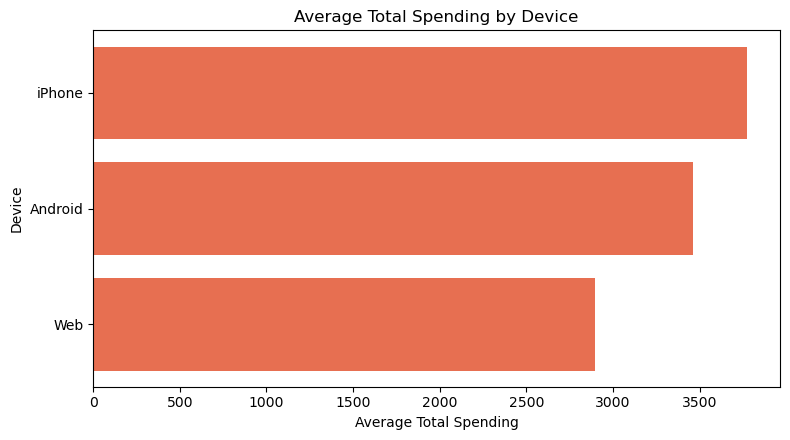

In [37]:
# Compare average customer spending by device
device_plot = device_summary.sort_values(
    "avg_total_spending"
)

plt.figure(figsize=(8, 4.5))

plt.barh(
    device_plot["device"],
    device_plot["avg_total_spending"],
    color="#E76F51"
)

plt.title("Average Total Spending by Device")
plt.xlabel("Average Total Spending")
plt.ylabel("Device")

plt.tight_layout()
plt.show()

In [38]:
# Summarize customer value by payment method
payment_summary = (
    factor_df
    .groupby("payment_method", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("suggested_total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

payment_summary = payment_summary[
    payment_summary["customer_count"] >= 3
].sort_values(
    "avg_total_spending",
    ascending=False
)

display(
    payment_summary.style.hide(axis="index")
)

payment_method,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
Card,18,3929.005000,18.777778,224.144444,4.388889,3.277778
Cash,19,3150.579474,19.210526,192.264737,4.421053,3.473684
Online Wallet,23,3104.462174,14.782609,221.815652,3.826087,2.347826


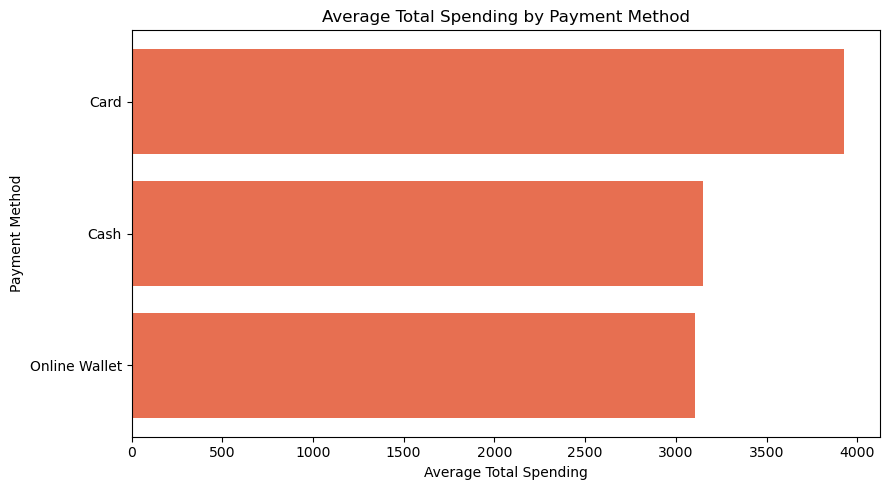

In [39]:
# Compare average customer spending by payment method
payment_plot = payment_summary.sort_values(
    "avg_total_spending"
)

plt.figure(figsize=(9, 5))

plt.barh(
    payment_plot["payment_method"],
    payment_plot["avg_total_spending"],
    color="#E76F51"
)

plt.title("Average Total Spending by Payment Method")
plt.xlabel("Average Total Spending")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

In [40]:
# Identify the device and payment method with the highest average customer spending
top_device = device_summary.loc[
    device_summary["avg_total_spending"].idxmax()
]

top_payment_method = payment_summary.loc[
    payment_summary["avg_total_spending"].idxmax()
]

print(
    f"Top device by average customer spending: "
    f"{top_device['device']} "
    f"({top_device['customer_count']} customers)"
)

print(
    f"Top payment method by average customer spending: "
    f"{top_payment_method['payment_method']} "
    f"({top_payment_method['customer_count']} customers)"
)

Top device by average customer spending: iPhone (18 customers)
Top payment method by average customer spending: Card (18 customers)


In [41]:
# Calculate descriptive differences between discount and non-discount groups
discount_comparison = summary_by_discount.set_index("discount_used")

comparison = pd.DataFrame({
    "Metric": [
        "Average Total Spending",
        "Average Purchase Count",
        "Average Order Value",
        "Average Returned Items",
        "Average Satisfaction"
    ],
    "Difference": [
        discount_comparison.loc[True, "avg_total_spending"]
        - discount_comparison.loc[False, "avg_total_spending"],

        discount_comparison.loc[True, "avg_purchase_count"]
        - discount_comparison.loc[False, "avg_purchase_count"],

        discount_comparison.loc[True, "avg_order_value"]
        - discount_comparison.loc[False, "avg_order_value"],

        discount_comparison.loc[True, "avg_returned_items"]
        - discount_comparison.loc[False, "avg_returned_items"],

        discount_comparison.loc[True, "avg_satisfaction"]
        - discount_comparison.loc[False, "avg_satisfaction"]
    ]
})

display(
    comparison.style.hide(axis="index")
)

Metric,Difference
Average Total Spending,-854.566946
Average Purchase Count,0.205882
Average Order Value,-17.409434
Average Returned Items,-0.187783
Average Satisfaction,0.504525


Important: This analysis describes observed relationships between discount usage, customer behavior, device, and payment method. It does not establish a causal relationship between these factors.

Customers who used discounts had a lower average total spending than customers who did not use discounts (2,882.17 vs. 3,736.74), despite having a slightly higher average purchase count (17.50 vs. 17.29). Their average order value was also lower (203.29 vs. 220.70). The average number of returned items was slightly lower among discount users (4.08 vs. 4.26), while their average satisfaction score was higher (3.27 vs. 2.76). These differences are based on 26 discount users and 34 non-discount users.

Among devices, iPhone customers had the highest average total spending (3,773.95) with 18 customers. Among payment methods, Card users had the highest average total spending (3,929.01) with 18 customers. These sample sizes are reasonable for descriptive comparison within this dataset, but the results should still be interpreted with caution.

This analysis does not establish a causal relationship between discounts and customer behavior. The observed differences may reflect differences in customer characteristics or other factors not included in the dataset.

### 6.Ceate a Five-Minute Executive Report for the CEO

In [42]:
# Create the six key business KPIs
kpi_summary = pd.Series(
    {
        "Unique Customers": df["customer_id"].nunique(),
        "Total Customer Spending": df["suggested_total_spending"].sum(),
        "Average Customer Spending": df["suggested_total_spending"].mean(),
        "Average Purchase Count": df["purchase_count"].mean(),
        "Average Satisfaction": df["satisfaction_score"].mean(),
        "Total Returned Items": df["returned_items"].sum()
    },
    name="Value"
)

display(
    kpi_summary.to_frame().style.format({"Value": "{:,.2f}"})
)

,Value
Unique Customers,60.00
Total Customer Spending,"201,985.73"
Average Customer Spending,"3,366.43"
Average Purchase Count,17.38
Average Satisfaction,2.98
Total Returned Items,251.00


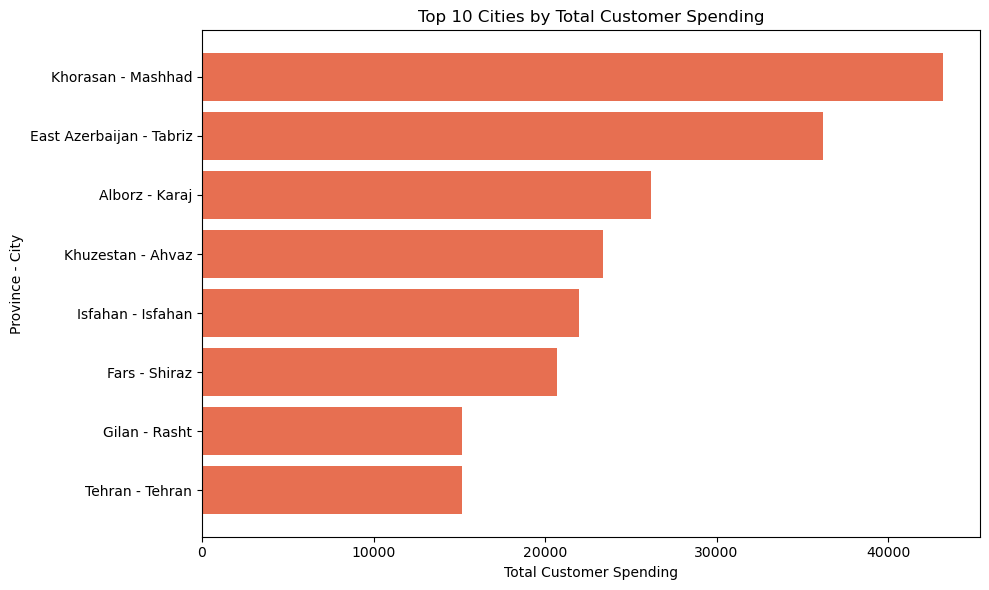

In [43]:
# Select the top 10 cities by total customer spending
chart1 = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

chart1_labels = (
    chart1["province"]
    + " - "
    + chart1["city"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart1_labels,
    chart1["total_revenue"],
    color="#E76F51"
)

plt.title("Top 10 Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")
plt.ylabel("Province - City")

plt.tight_layout()
plt.show()

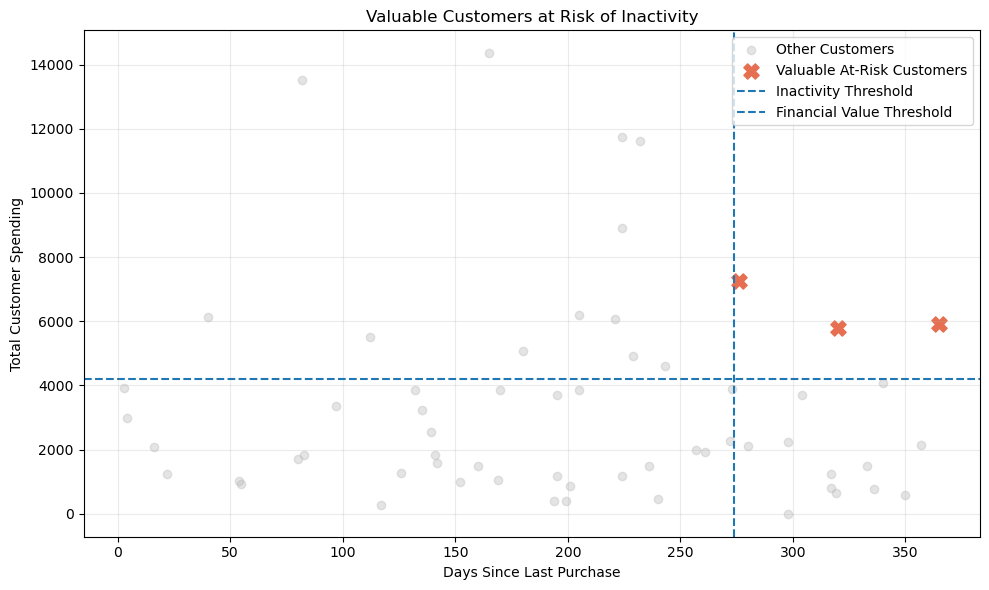

In [44]:
# Plot valuable customers at risk of inactivity
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "suggested_total_spending"],
    alpha=0.4,
    color="#BDBDBD",
    label="Other Customers"
)

plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "suggested_total_spending"],
    marker="X",
    s=120,
    color="#E76F51",
    label="Valuable At-Risk Customers"
)

plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label="Inactivity Threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label="Financial Value Threshold"
)

plt.title("Valuable Customers at Risk of Inactivity")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Customer Spending")

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

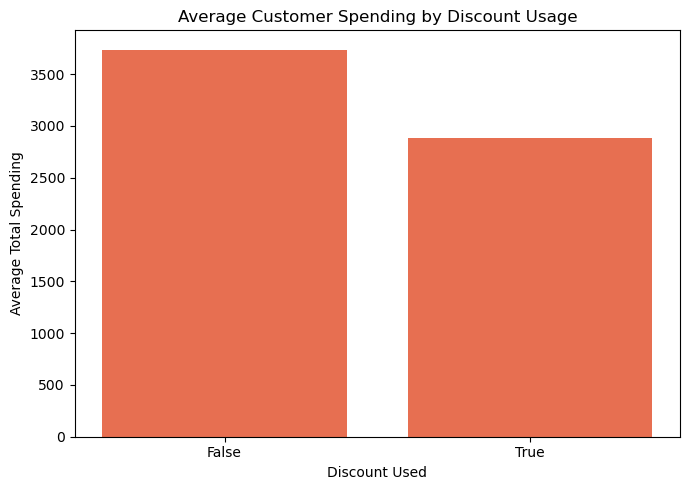

In [45]:
# Compare average customer spending by discount usage
plt.figure(figsize=(7, 5))

plt.bar(
    summary_by_discount["discount_used"].astype(str),
    summary_by_discount["avg_total_spending"],
    color="#E76F51"
)

plt.title("Average Customer Spending by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Total Spending")

plt.tight_layout()
plt.show()

In [48]:
# Create three managerial recommendations using Evidence -> Action -> KPI structure

management_recommendations = pd.DataFrame({
    "Evidence": [
        "Mashhad has the highest total customer spending among the analyzed cities.",
        "Three valuable customers are currently in the high-value, high-inactivity region.",
        "Discount users have lower average spending but higher average satisfaction than non-discount users."
    ],
    "Action": [
        "Prioritize Mashhad for targeted advertising while monitoring customer satisfaction.",
        "Launch personalized win-back campaigns for the identified at-risk customers.",
        "Use customer-level segmentation before expanding discounts instead of applying discounts broadly."
    ],
    "KPI": [
        "Revenue growth and customer acquisition in Mashhad",
        "Reactivation rate and repeat purchase rate",
        "Average customer spending and average returned items per customer among targeted discount users"
    ]
})

display(
    management_recommendations.style.hide(axis="index")
)

Evidence,Action,KPI
Mashhad has the highest total customer spending among the analyzed cities.,Prioritize Mashhad for targeted advertising while monitoring customer satisfaction.,Revenue growth and customer acquisition in Mashhad
"Three valuable customers are currently in the high-value, high-inactivity region.",Launch personalized win-back campaigns for the identified at-risk customers.,Reactivation rate and repeat purchase rate
Discount users have lower average spending but higher average satisfaction than non-discount users.,Use customer-level segmentation before expanding discounts instead of applying discounts broadly.,Average customer spending and average returned items per customer among targeted discount users


In [49]:
import os
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# Define output file
output_file = "customer_analytics_results.xlsx"

# Create temporary folder for chart images
chart_folder = "excel_charts"
os.makedirs(chart_folder, exist_ok=True)

# Create Excel workbook
with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # Question 1
    summary_table.to_excel(
        writer,
        sheet_name="Q1_Customer_Profile",
        index=False,
        startrow=0
    )

    # Question 2
    city_comparison.to_excel(
        writer,
        sheet_name="Q2_Location",
        index=False,
        startrow=0
    )

    # Question 3
    top_loyal_customers.to_excel(
        writer,
        sheet_name="Q3_Loyalty",
        index=False,
        startrow=0
    )

    # Question 4
    at_risk_customers.to_excel(
        writer,
        sheet_name="Q4_At_Risk",
        index=False,
        startrow=0
    )

    # Question 5
    summary_by_discount.to_excel(
        writer,
        sheet_name="Q5_Discount",
        index=False,
        startrow=0
    )

    device_summary.to_excel(
        writer,
        sheet_name="Q5_Discount",
        index=False,
        startrow=len(summary_by_discount) + 4
    )

    payment_summary.to_excel(
        writer,
        sheet_name="Q5_Discount",
        index=False,
        startrow=len(summary_by_discount) + len(device_summary) + 8
    )

    comparison.to_excel(
        writer,
        sheet_name="Q5_Discount",
        index=False,
        startrow=len(summary_by_discount)
        + len(device_summary)
        + len(payment_summary)
        + 12
    )

    # Question 6
    kpi_summary.to_frame().to_excel(
        writer,
        sheet_name="Q6_Executive",
        index=True,
        startrow=0
    )

    management_recommendations.to_excel(
        writer,
        sheet_name="Q6_Executive",
        index=False,
        startrow=9
    )


# Load workbook for formatting and adding charts
wb = load_workbook(output_file)


# ---------------------------------------------------------
# Helper function for worksheet formatting
# ---------------------------------------------------------

def format_sheet(ws):

    # Freeze the first row
    ws.freeze_panes = "A2"

    # Format header row
    for cell in ws[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(
            horizontal="center",
            vertical="center"
        )

    # Adjust column widths
    for column_cells in ws.columns:
        max_length = 0
        column_letter = get_column_letter(column_cells[0].column)

        for cell in column_cells:
            if cell.value is not None:
                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        ws.column_dimensions[column_letter].width = min(
            max_length + 3,
            35
        )


# ---------------------------------------------------------
# Create and save Question 1 charts
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
age_distribution.plot(
    kind="bar",
    color="#E76F51"
)
plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
q1_age = os.path.join(chart_folder, "q1_age.png")
plt.savefig(q1_age, dpi=150)
plt.close()


plt.figure(figsize=(8, 5))
membership_distribution.plot(
    kind="bar",
    color="#E76F51"
)
plt.title("Customer Distribution by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
q1_membership = os.path.join(chart_folder, "q1_membership.png")
plt.savefig(q1_membership, dpi=150)
plt.close()


plt.figure(figsize=(8, 5))
device_distribution.plot(
    kind="bar",
    color="#E76F51"
)
plt.title("Customer Distribution by Device")
plt.xlabel("Device")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
q1_device = os.path.join(chart_folder, "q1_device.png")
plt.savefig(q1_device, dpi=150)
plt.close()


plt.figure(figsize=(9, 5))
payment_distribution.plot(
    kind="bar",
    color="#E76F51"
)
plt.title("Customer Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
q1_payment = os.path.join(chart_folder, "q1_payment.png")
plt.savefig(q1_payment, dpi=150)
plt.close()


# ---------------------------------------------------------
# Create Question 2 charts
# ---------------------------------------------------------

chart1 = (
    city_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

labels = (
    chart1["province"]
    + " - "
    + chart1["city"]
)

plt.figure(figsize=(10, 6))
plt.barh(
    labels,
    chart1["total_revenue"],
    color="#E76F51"
)
plt.title("Top 10 Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")
plt.ylabel("Province - City")
plt.tight_layout()

q2_cities = os.path.join(chart_folder, "q2_top_cities.png")
plt.savefig(q2_cities, dpi=150)
plt.close()


plt.figure(figsize=(10, 7))
plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65,
    color="#E76F51"
)

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("City Financial Value vs. Customer Satisfaction")
plt.xlabel("Total Customer Spending")
plt.ylabel("Average Customer Satisfaction")
plt.grid(alpha=0.25)
plt.tight_layout()

q2_scatter = os.path.join(chart_folder, "q2_city_scatter.png")
plt.savefig(q2_scatter, dpi=150)
plt.close()


# ---------------------------------------------------------
# Create Question 3 chart
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["suggested_total_spending"],
    s=(loyalty_df["recency_score"] + 0.15) * 140,
    alpha=0.6,
    color="#E76F51"
)

plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["suggested_total_spending"],
    s=180,
    marker="*",
    color="#7A3E9D",
    label="Top 10 Selected Customers"
)

plt.title("Purchase Frequency vs. Total Customer Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Customer Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

q3_loyalty = os.path.join(chart_folder, "q3_loyalty.png")
plt.savefig(q3_loyalty, dpi=150)
plt.close()


# ---------------------------------------------------------
# Create Question 4 chart
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "suggested_total_spending"],
    alpha=0.45,
    color="#BDBDBD",
    label="Other Customers"
)

plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "suggested_total_spending"],
    marker="X",
    s=120,
    color="#E76F51",
    label="Valuable At-Risk Customers"
)

plt.axvline(
    inactivity_threshold,
    linestyle="--",
    color="#7A3E9D",
    label="Inactivity Threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    color="#7A3E9D",
    label="Financial Value Threshold"
)

plt.title("Valuable Customers at Risk of Inactivity")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Customer Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

q4_risk = os.path.join(chart_folder, "q4_at_risk.png")
plt.savefig(q4_risk, dpi=150)
plt.close()


# ---------------------------------------------------------
# Create Question 5 charts
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.bar(
    summary_by_discount["discount_used"].astype(str),
    summary_by_discount["avg_total_spending"],
    color="#E76F51"
)
plt.title("Average Customer Spending by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Total Spending")
plt.tight_layout()

q5_discount_spending = os.path.join(
    chart_folder,
    "q5_discount_spending.png"
)
plt.savefig(q5_discount_spending, dpi=150)
plt.close()


plt.figure(figsize=(7, 5))
plt.bar(
    summary_by_discount["discount_used"].astype(str),
    summary_by_discount["avg_returned_items"],
    color="#E76F51"
)
plt.title("Average Returned Items by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Returned Items")
plt.tight_layout()

q5_discount_returns = os.path.join(
    chart_folder,
    "q5_discount_returns.png"
)
plt.savefig(q5_discount_returns, dpi=150)
plt.close()


device_plot = device_summary.sort_values(
    "avg_total_spending"
)

plt.figure(figsize=(8, 5))
plt.barh(
    device_plot["device"],
    device_plot["avg_total_spending"],
    color="#E76F51"
)
plt.title("Average Total Spending by Device")
plt.xlabel("Average Total Spending")
plt.ylabel("Device")
plt.tight_layout()

q5_device = os.path.join(
    chart_folder,
    "q5_device.png"
)
plt.savefig(q5_device, dpi=150)
plt.close()


payment_plot = payment_summary.sort_values(
    "avg_total_spending"
)

plt.figure(figsize=(9, 5))
plt.barh(
    payment_plot["payment_method"],
    payment_plot["avg_total_spending"],
    color="#E76F51"
)
plt.title("Average Total Spending by Payment Method")
plt.xlabel("Average Total Spending")
plt.ylabel("Payment Method")
plt.tight_layout()

q5_payment = os.path.join(
    chart_folder,
    "q5_payment.png"
)
plt.savefig(q5_payment, dpi=150)
plt.close()


# ---------------------------------------------------------
# Insert charts into Excel sheets
# ---------------------------------------------------------

# Question 1
ws = wb["Q1_Customer_Profile"]

for i, chart in enumerate(
    [q1_age, q1_membership, q1_device, q1_payment]
):
    img = Image(chart)
    img.width = 480
    img.height = 300
    ws.add_image(
        img,
        f"F{1 + i * 18}"
    )


# Question 2
ws = wb["Q2_Location"]

img = Image(q2_cities)
img.width = 600
img.height = 360
ws.add_image(img, "J2")

img = Image(q2_scatter)
img.width = 600
img.height = 420
ws.add_image(img, "J22")


# Question 3
ws = wb["Q3_Loyalty"]

img = Image(q3_loyalty)
img.width = 650
img.height = 390
ws.add_image(img, "J2")


# Question 4
ws = wb["Q4_At_Risk"]

img = Image(q4_risk)
img.width = 650
img.height = 390
ws.add_image(img, "J2")


# Question 5
ws = wb["Q5_Discount"]

charts_q5 = [
    q5_discount_spending,
    q5_discount_returns,
    q5_device,
    q5_payment
]

for i, chart in enumerate(charts_q5):
    img = Image(chart)
    img.width = 500
    img.height = 320
    ws.add_image(
        img,
        f"J{2 + i * 20}"
    )


# Question 6
ws = wb["Q6_Executive"]

# Add the three selected executive charts
img = Image(q2_cities)
img.width = 520
img.height = 310
ws.add_image(img, "F2")

img = Image(q4_risk)
img.width = 520
img.height = 310
ws.add_image(img, "F20")

img = Image(q5_discount_spending)
img.width = 520
img.height = 310
ws.add_image(img, "F38")


# ---------------------------------------------------------
# Format all worksheets
# ---------------------------------------------------------

for ws in wb.worksheets:
    format_sheet(ws)


# Save final workbook
wb.save(output_file)

print(f"Excel file created successfully: {output_file}")

Excel file created successfully: customer_analytics_results.xlsx
